In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService

In [1]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Option A (common): save for later use (interactive)
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="ecR3FMqYgI2fN3FgmihayIDivcFs03b3losWCdyMp_z0",
    # instance may be required depending on your plan/org:
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/6cd07db216044aa69a3eda399cb5cccc:f9f78960-9fcc-4854-8dd9-09ba43540245::",  # example format; use your actual instance
    overwrite=True,
)

# Later in scripts/notebooks:
#service = QiskitRuntimeService(channel="ibm_quantum_platform")

In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel="ibm_quantum_platform")

# List backends you can access
backends = service.backends()
print("Number of backends:", len(backends))

for b in backends[:10]:
    print(b.name)

Number of backends: 3
ibm_fez
ibm_marrakesh
ibm_torino


Test of circuit

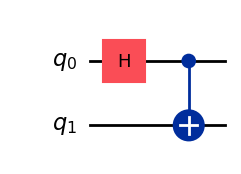

In [3]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorOptions
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from matplotlib import pyplot as plt
# Uncomment the next line if you want to use a simulator:
# from qiskit_ibm_runtime.fake_provider import FakeBelemV2
 
 
# Create a new circuit with two qubits
qc = QuantumCircuit(2)
 
# Add a Hadamard gate to qubit 0
qc.h(0)
 
# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)
 
# Return a drawing of the circuit using MatPlotLib ("mpl").
# These guides are written by using Jupyter notebooks, which
# display the output of the last line of each cell.
# If you're running this in a script, use `print(qc.draw())` to
# print a text drawing.
qc.draw("mpl")

**Task (b)**

In [6]:
from matplotlib import pyplot as plt
import numpy as np
from numpy import linalg

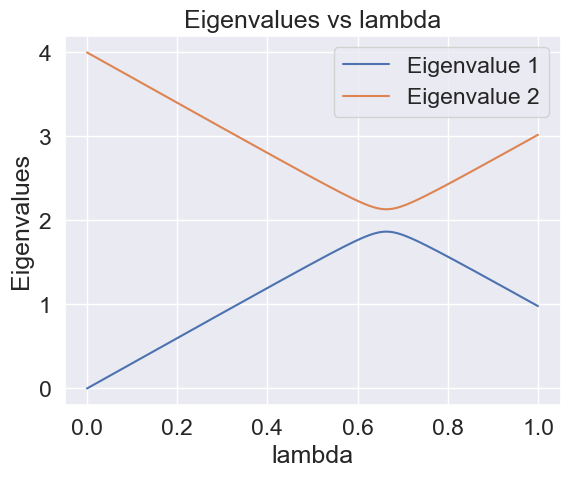

In [5]:
# Defining variables and setting up the Hamiltonian

E1 = 0
E2 = 4
V11 = 3
V22 = -V11
V12 = V21 = 0.2


def hamiltonian(l=0.0):
    H_0 = np.array([[E1, 0], [0, E2]])
    H_i = np.array([[V11, V21], [V12, V22]])    
    return np.array(H_0 + l*H_i)

real = [[3, 0.2], [0.2, -3]]

N = 500
lams = np.linspace(0, 1, N)

eigvals = np.zeros((N, 2))

for i, lam in enumerate(lams):
    w, v = np.linalg.eigh(hamiltonian(lam))
    eigvals[i, :] = w

# Plot
plt.plot(lams, eigvals[:, 0], label="Eigenvalue 1")
plt.plot(lams, eigvals[:, 1], label="Eigenvalue 2")

plt.xlabel("lambda")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues vs lambda")
plt.legend()
plt.grid(True)
plt.show()

**Task c (VQE)**

In [41]:
# Define variables
eps = (E1+E2)/2
omega = (E1-E2)/2
c = (V11+V22)/2
w_z = (V11-V22)/2
w_x = V12

# Define operators
def r_x(theta=np.pi/2):
    return np.array([[np.cos(theta/2), -1j*np.sin(theta/2)], [-1j*np.sin(theta/2), np.cos(theta/2)]])

def r_y(phi=np.pi/2):
    return np.array([[np.cos(phi/2), np.sin(phi/2)], [np.sin(phi/2), np.sin(phi/2)]])

def Z():
    return np.array([[1,0],[0,-1]])

def X():
    return np.array([[0,1],[1,0]])

def identity():
    return np.eye(2)

# Define computational basis and state
c0 = [1, 0]
c1 = [0, 1]
def state(theta, phi):
    return r_y(phi=phi)@r_x(theta=theta)@c0

# Define functions to be used in VQE

def expectation_value(operator, theta, phi):
    """Measures expectation value for each operator"""
    return state(theta,phi).conj().T@operator@state(theta,phi)

def e_int(c, w_z, w_x, theta, phi):
    """Returns energy for interacting Hamiltonian"""
    return c*expectation_value(identity(), theta, phi) + w_z*expectation_value(Z(), theta, phi) + w_x*expectation_value(X(), theta, phi)

def e_ground(eps, omega, theta, phi):
    """Returns energy for ground state Hamiltonian"""
    return eps*expectation_value(identity(), theta, phi) + omega*expectation_value(Z(), theta, phi)

def measurement(theta, phi):
    """Returns total energy for full Hamiltonian"""
    total_energy = e_ground(eps,omega, theta, phi) + e_int(c,w_z,w_x, theta, phi)
    return total_energy

def theta_grad(theta=np.pi/2, phi=np.pi/2):
    return 0.5*(measurement(theta+np.pi/2, phi) - measurement(theta-np.pi/2, phi))

def phi_grad(theta=np.pi/2,phi=np.pi/2):
    return 0.5*(measurement(theta, phi+np.pi/2)-measurement(theta, phi-np.pi/2))

def optimizer():
    """Does Gradient descent and returns the best parameters (theta, phi) to minimize the energy"""
    eta = 1e01
    theta = np.pi/2
    phi = theta
    for iter in range(1000):
        theta -= eta*theta_grad()
        phi -= eta*phi_grad()

    print(theta, phi, measurement(theta,phi))

optimizer()

(1.5707963267948966+0j) (-5998.429203673206+0j) (2.447022858595801+0j)
